In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [2]:
df=pd.read_excel("premiums_young.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857


In [3]:
df.shape

(20096, 13)

In [4]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [5]:
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857


In [6]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handle NA value 

In [7]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Duplicate handling

In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [10]:
df[df['number_of_dependants'] < 0].shape

(22, 13)

In [11]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-3, -1])

In [12]:
df['number_of_dependants'] = abs(df['number_of_dependants'])

In [13]:
df[df['number_of_dependants'] < 0].shape

(0, 13)

In [14]:
df['number_of_dependants'].describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

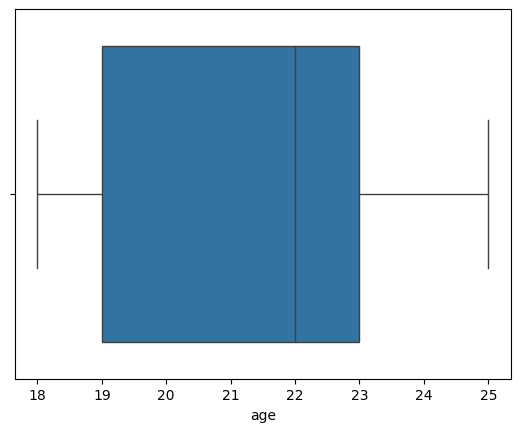

In [15]:
sns.boxplot(x=df['age'])
plt.show()

In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns

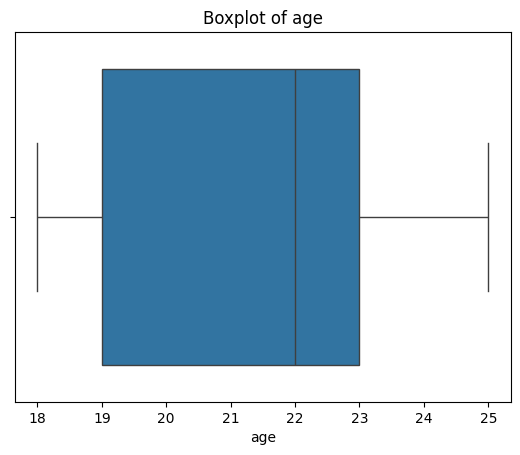

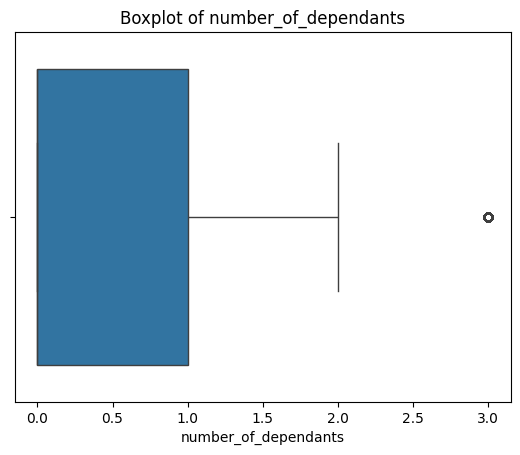

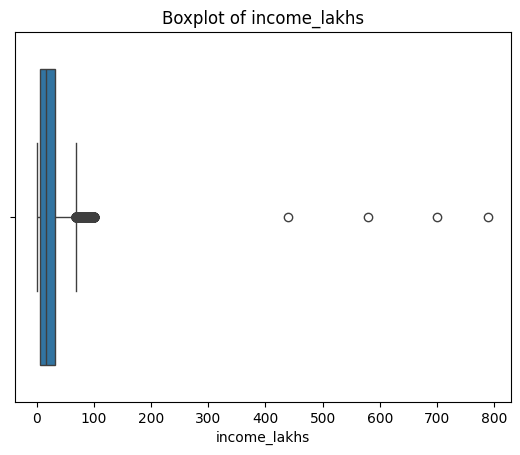

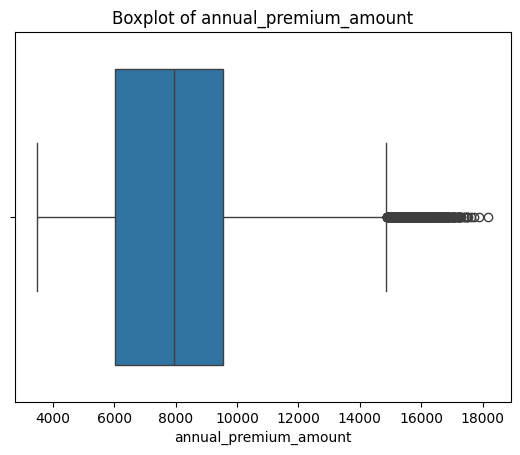

In [17]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [18]:
df[df.age>100]['age'].unique()

array([], dtype=int64)

In [19]:
df1 = df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


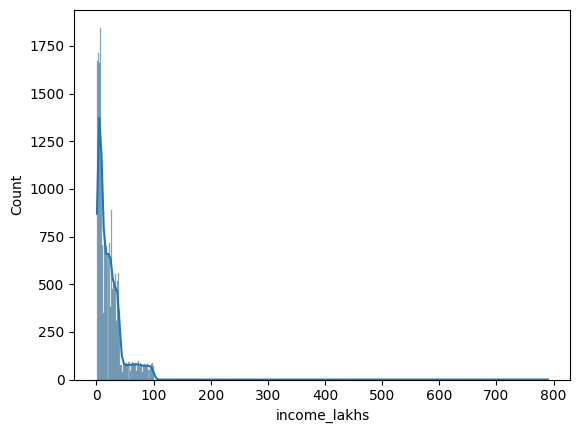

In [20]:
sns.histplot(df1.income_lakhs, kde=True)
plt.show()

In [21]:
df1.income_lakhs.quantile([0.25, 0.75])


0.25     6.0
0.75    31.0
Name: income_lakhs, dtype: float64

In [22]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [23]:
get_iqr_bounds(df1.income_lakhs)

(-31.5, 68.5)

In [24]:
quantile_threshold = df1.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [25]:
df1[df1.income_lakhs > quantile_threshold].shape

(4, 13)

In [26]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263
std,2.294248,0.937238,21.732062,2749.912486
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,100.000000,18186.000000


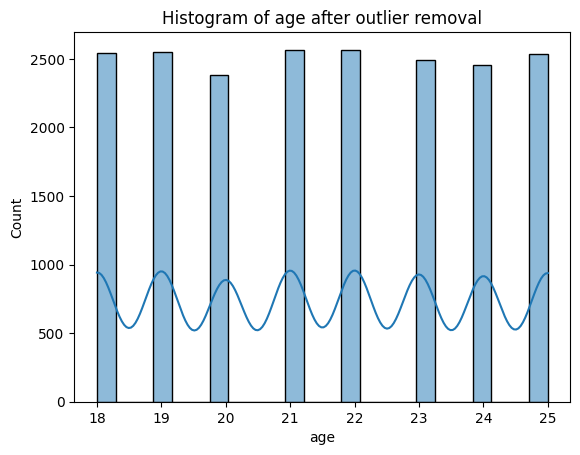

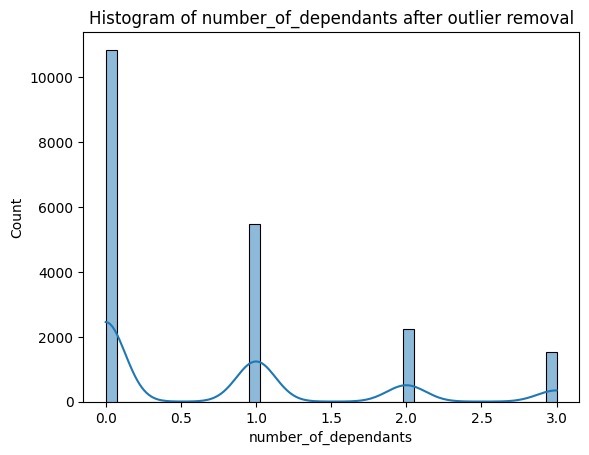

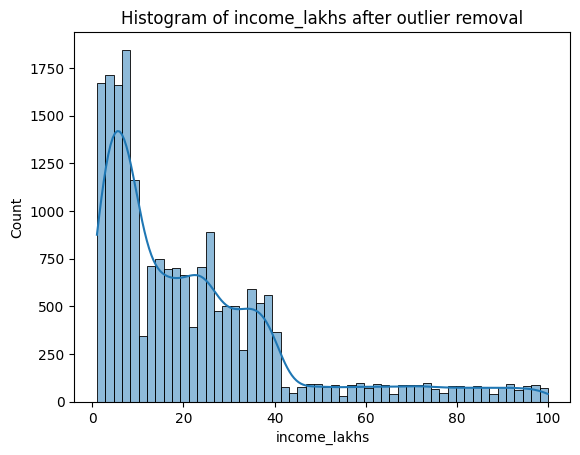

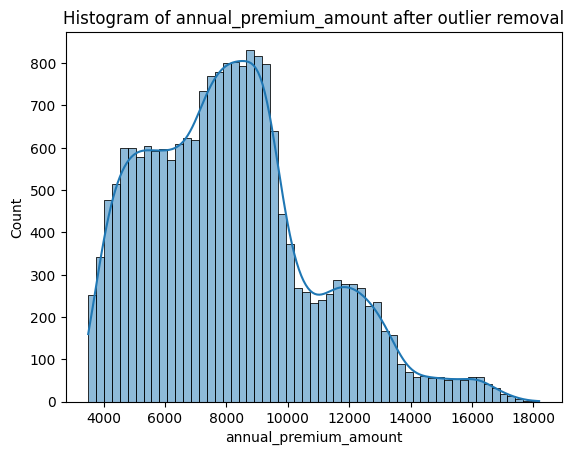

In [27]:

for col in numeric_columns:
    sns.histplot(df2[col], kde=True)
    plt.title(f'Histogram of {col} after outlier removal')
    plt.show()

plt.show()

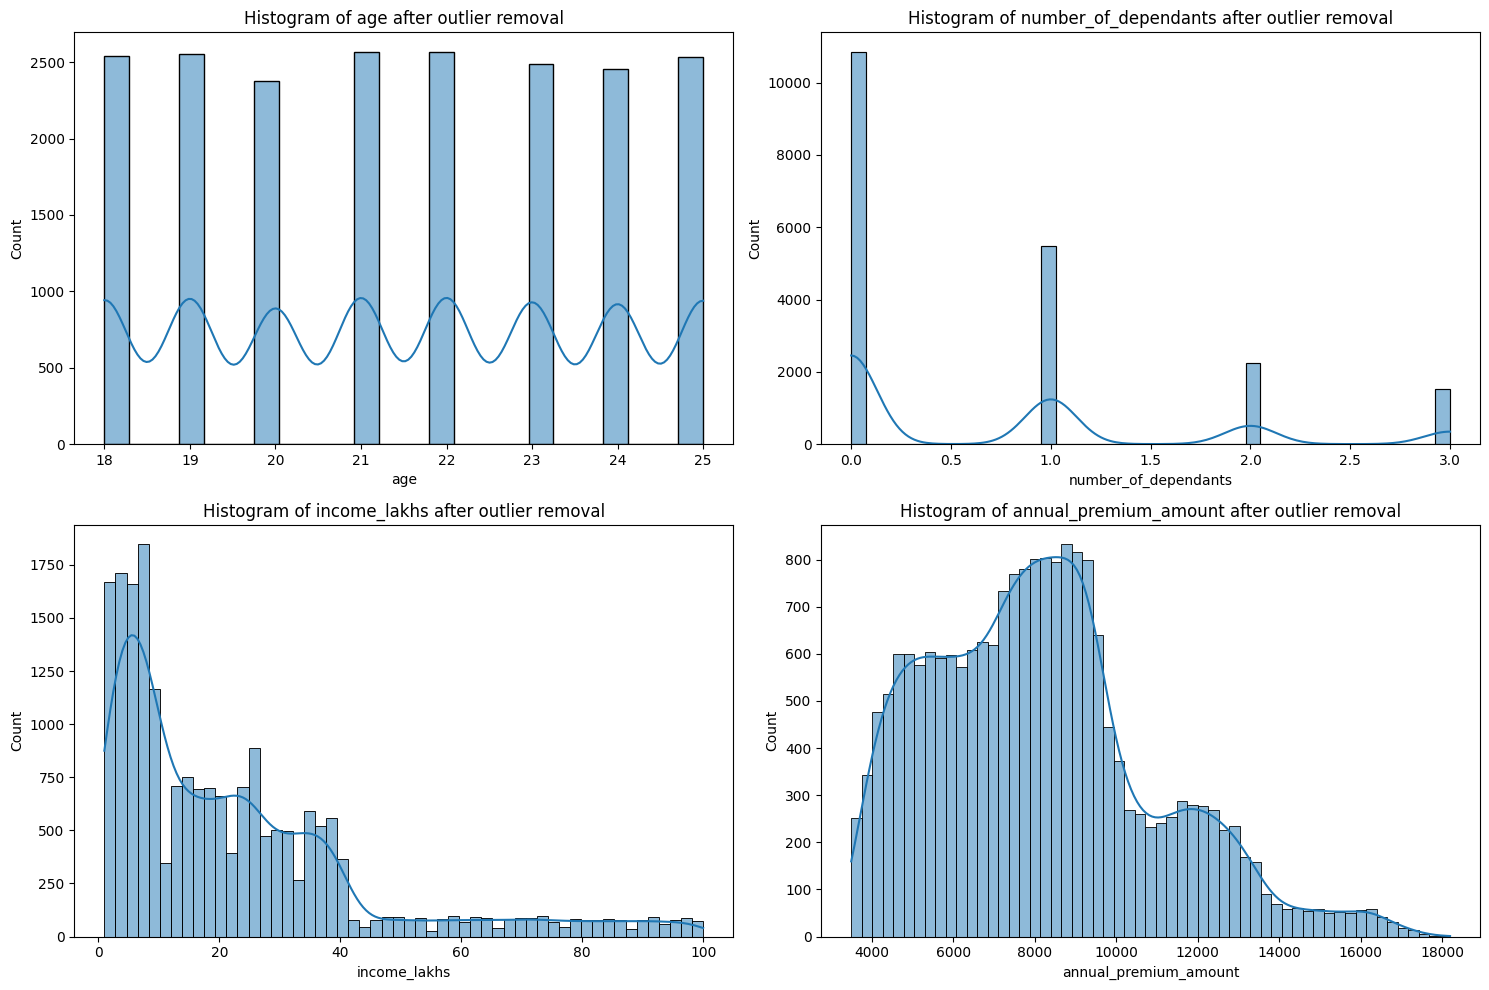

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.histplot(df2[col], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Histogram of {col} after outlier removal')
plt.tight_layout()
plt.show()

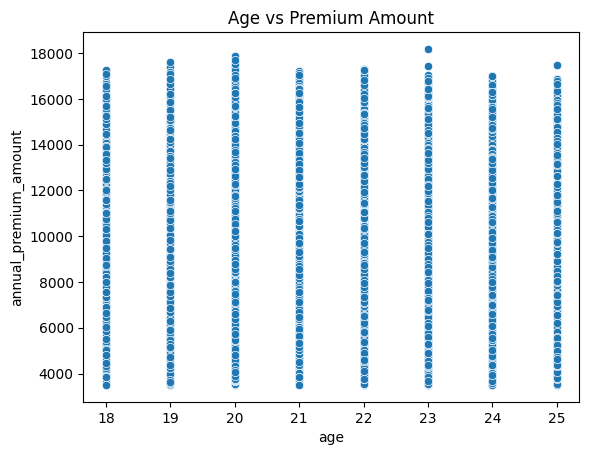

In [29]:
sns.scatterplot(x=df2['age'], y=df2['annual_premium_amount'])
plt.title('Age vs Premium Amount')
plt.show()

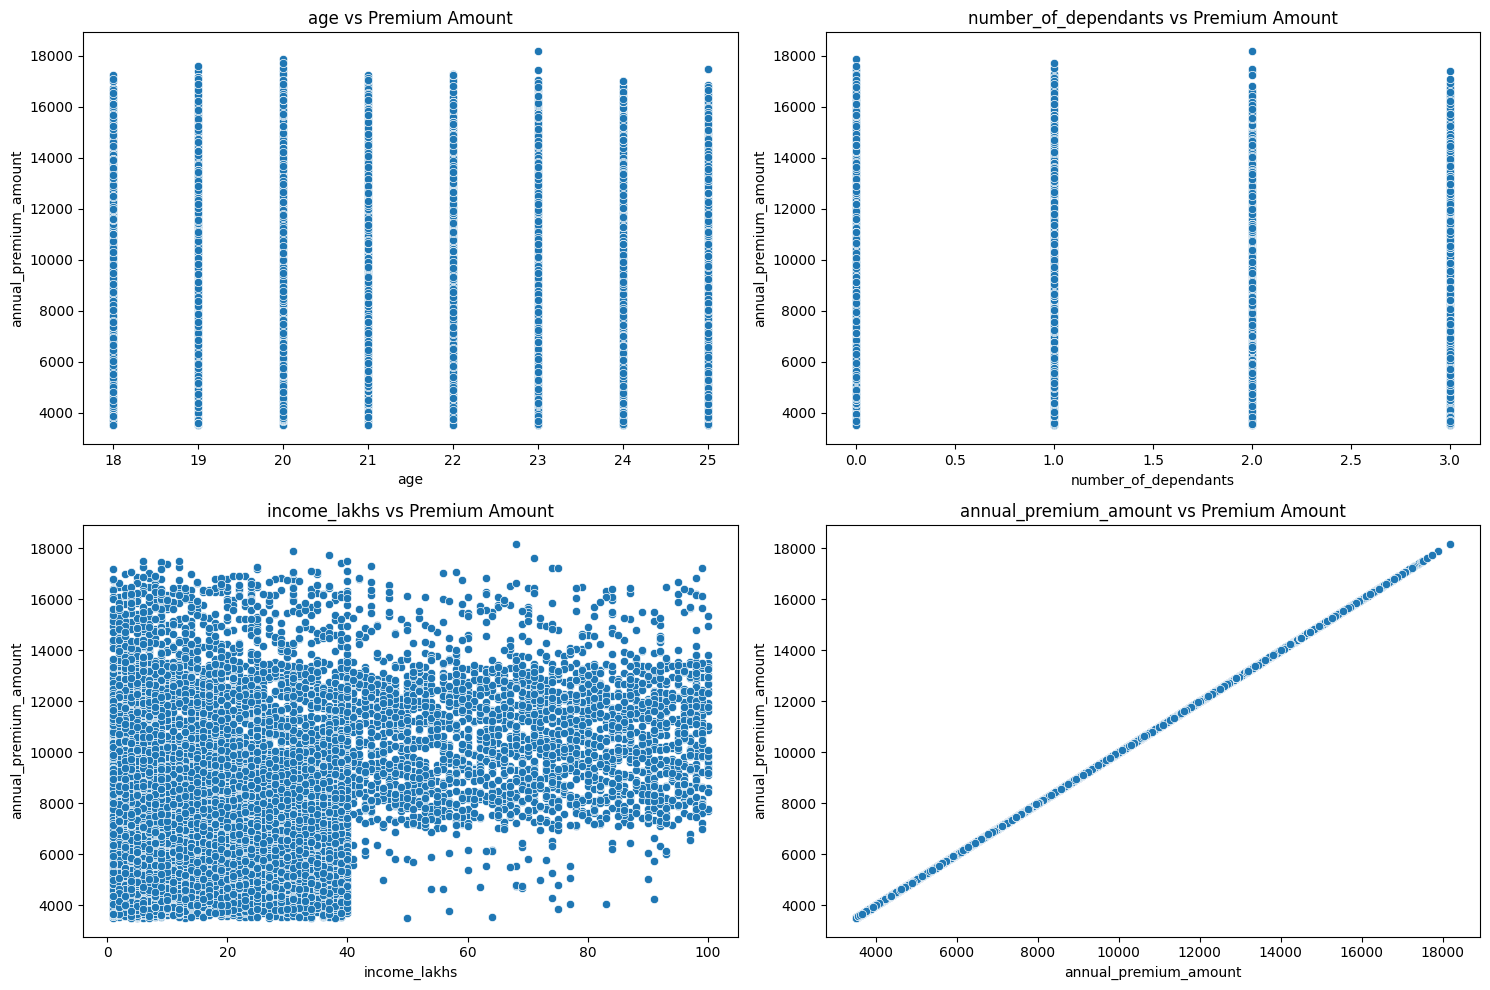

In [30]:
# two layouts for scatter plots
numeric_columns = df2.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.scatterplot(x=df2[col], y=df2['annual_premium_amount'], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{col} vs Premium Amount')
plt.tight_layout()
plt.show()


In [31]:
categorical_columns = df2.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f'Value counts for {col}:')
    print(df2[col].unique())

Value counts for gender:
['Male' 'Female']
Value counts for region:
['Northeast' 'Northwest' 'Southeast' 'Southwest']
Value counts for marital_status:
['Unmarried' 'Married']
Value counts for bmi_category:
['Overweight' 'Underweight' 'Normal' 'Obesity']
Value counts for smoking_status:
['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
Value counts for employment_status:
['Self-Employed' 'Freelancer' 'Salaried']
Value counts for income_level:
['> 40L' '<10L' '10L - 25L' '25L - 40L']
Value counts for medical_history:
['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
Value counts for insurance_plan:
['Silver' 'Bronze' 'Gold']


In [32]:
df2['smoking_status'].replace(
    {
        'Smoking=0':'No Smoking',
         'Does Not Smoke':'No Smoking',
         'Not Smoking':'No Smoking',
    },
    inplace=True
)
df2['smoking_status'].unique()

C:\Users\hapatil\AppData\Local\Temp\ipykernel_23732\2684999231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['smoking_status'].replace(


array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

In [33]:
ptc_count =df2['gender'].value_counts(normalize=True)
ptc_count

gender
Male      0.550383
Female    0.449617
Name: proportion, dtype: float64

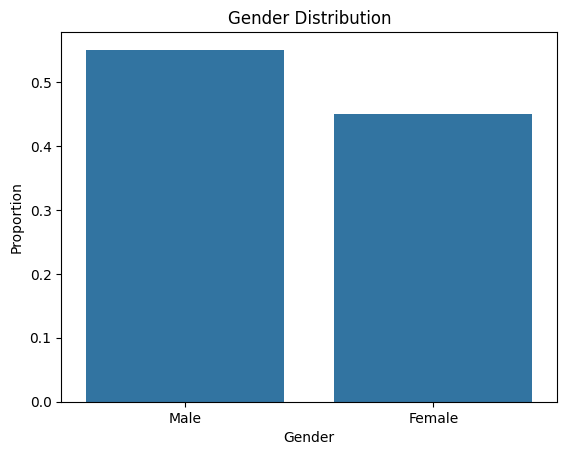

In [34]:
sns.barplot(x=ptc_count.index, y=ptc_count.values)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Proportion')    
plt.show()

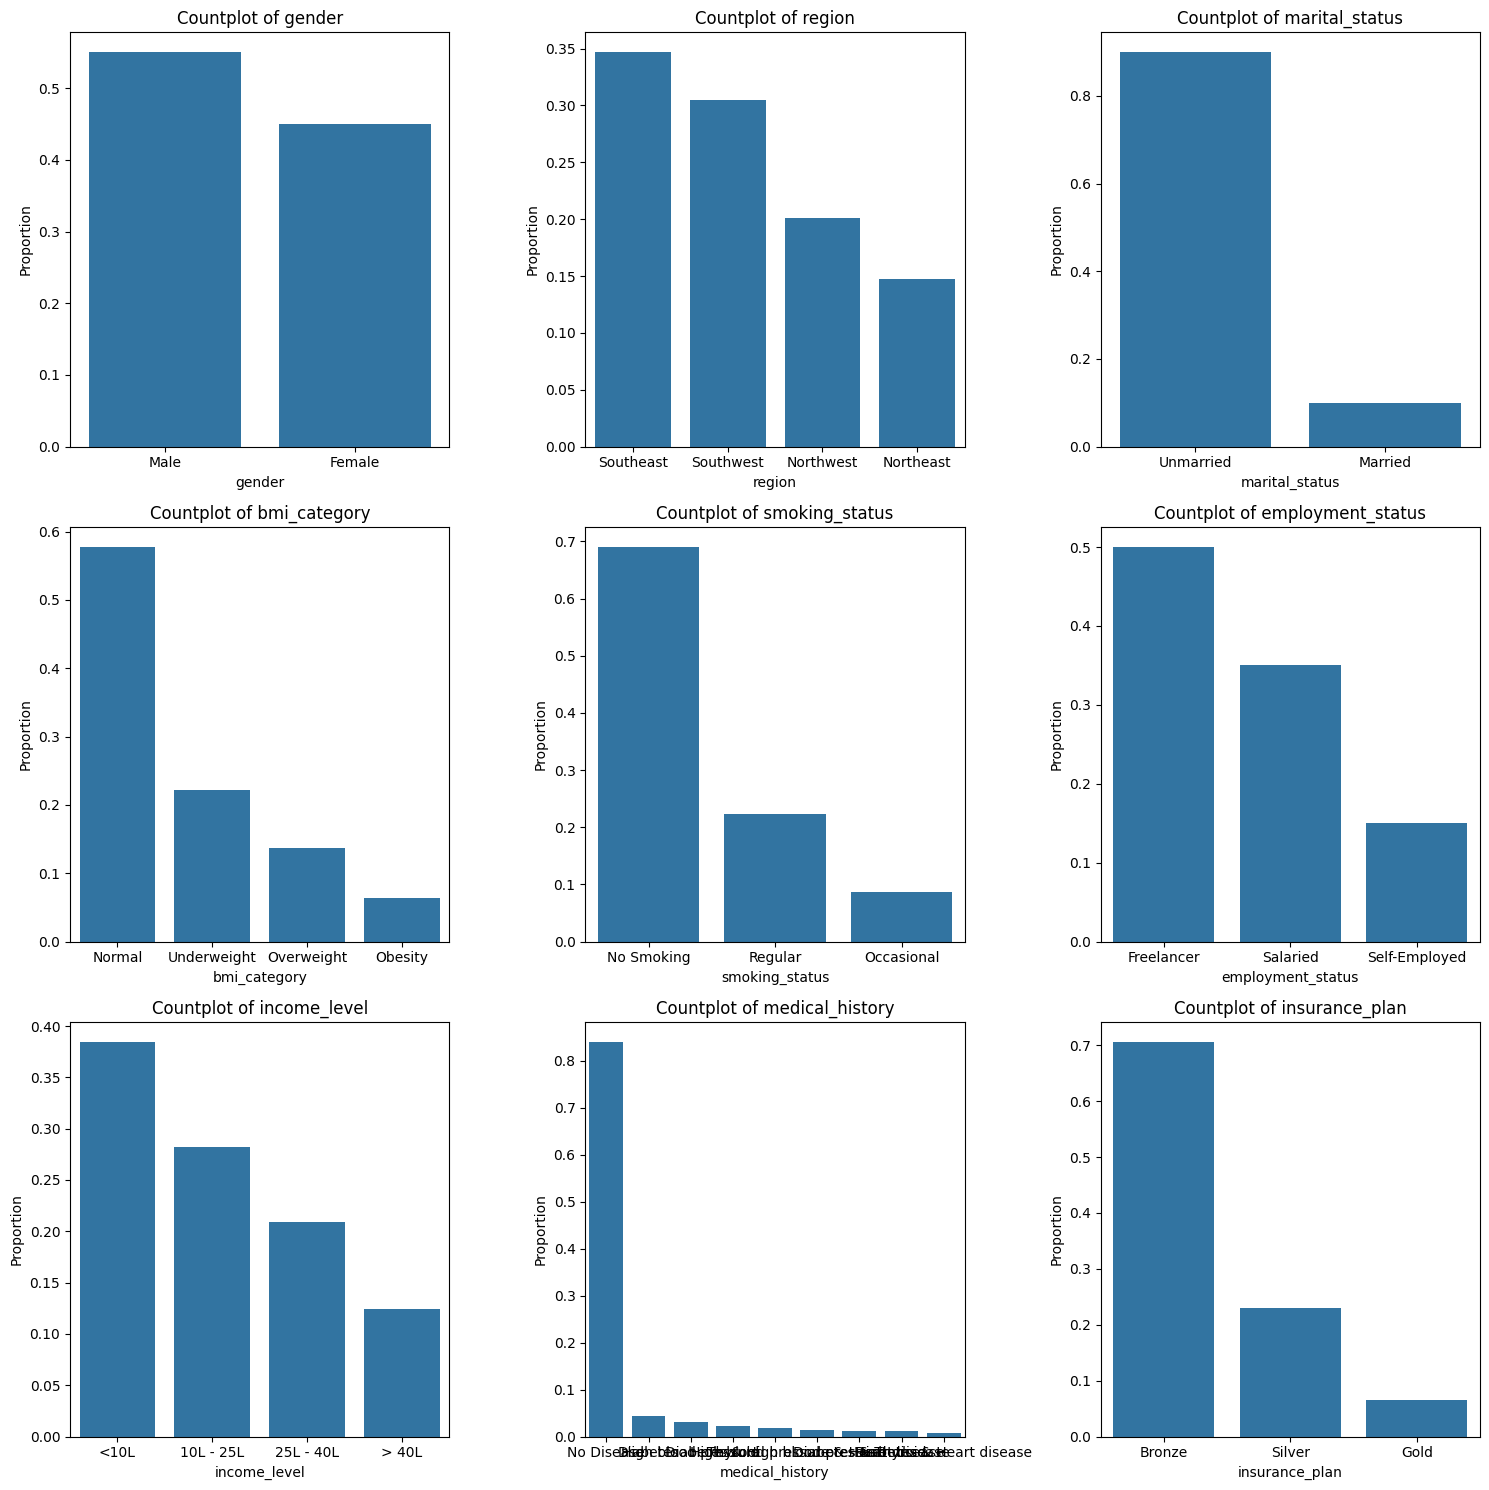

In [35]:
import math

n_plots = len(categorical_columns)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_columns):
    counts = df2[col].value_counts(normalize=True)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')

# Hide any unused subplot axes
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

insurance_plan  Bronze  Gold  Silver
income_range                        
<10L              6172   404    1145
10L-25L           4203   307     779
25L-40L           3473   216     606
>40L               329   378    2074


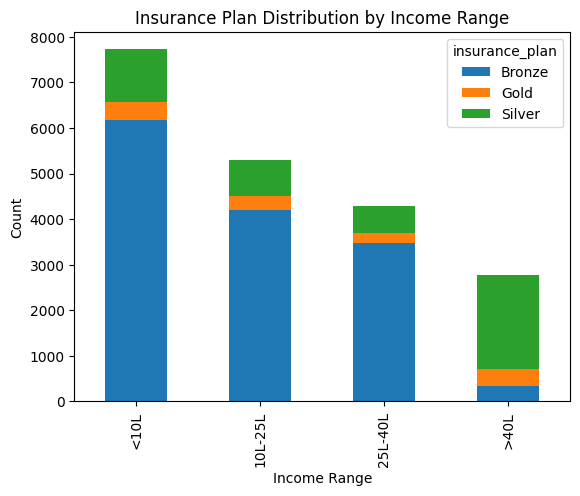

In [36]:
# Create income ranges in lakhs
income_bins = [float('-inf'), 10, 25, 40, float('inf')]
income_labels = ['<10L', '10L-25L', '25L-40L', '>40L']

df2['income_range'] = pd.cut(
    df2['income_lakhs'],
    bins=income_bins,
    labels=income_labels,
    right=False
 )

crosstab = pd.crosstab(df2['income_range'], df2['insurance_plan'])
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Insurance Plan Distribution by Income Range')
plt.xlabel('Income Range')
plt.ylabel('Count')
plt.show()

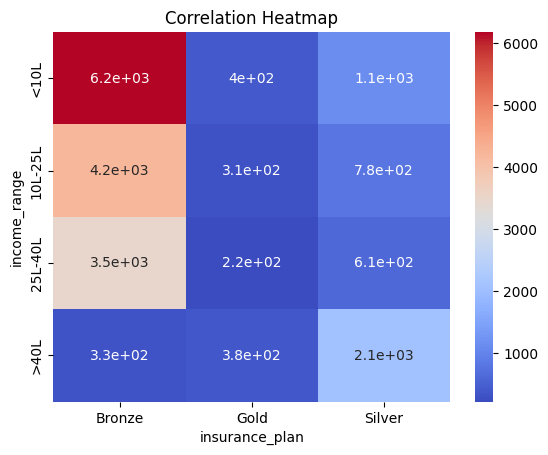

In [37]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')    
plt.show()

In [38]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,>40L
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,<10L
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,>40L
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,10L-25L
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,10L-25L


In [39]:
df2.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [40]:
risk_scores = {
    "diabetes": 6, 
    "high blood pressure": 6, 
    "no disease": 0,
    "thyroid": 5, 
    "heart disease": 8,
    "none": 0       
}

In [41]:
df2[["disease1","disease2"]] = df2.medical_history.str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,>40L,high blood pressure,None
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,<10L,no disease,None
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,>40L,no disease,None
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,10L-25L,no disease,None
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,10L-25L,no disease,None


In [42]:
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)

df2['total_risk_score'] = 0

for disease_col in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease_col].map(risk_scores)

max_risk_score = df2['total_risk_score'].max()
min_risk_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_risk_score) / (max_risk_score - min_risk_score)
df2.head(5)

C:\Users\hapatil\AppData\Local\Temp\ipykernel_23732\3450494256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['disease1'].fillna('none', inplace=True)
C:\Users\hapatil\AppData\Local\Temp\ipykernel_23732\3450494256.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,>40L,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,<10L,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,>40L,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,10L-25L,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,10L-25L,no disease,none,0,0.000000


In [43]:
df2.insurance_plan.unique()

array(['Silver', 'Bronze', 'Gold'], dtype=object)

In [44]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df2.head()
df2['insurance_plan'].unique()

array([2, 1, 3])

In [45]:
df2['income_level'].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [46]:
df2['income_level'] = df2['income_level'].map({'<10L': 1, '10L - 25L': 2, '25L - 40L': 3, '> 40L': 4})
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,4,99,High blood pressure,2,13365,>40L,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,1,3,No Disease,2,11050,<10L,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,4,97,No Disease,2,11857,>40L,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,2,15,No Disease,1,5684,10L-25L,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,2,14,No Disease,1,5712,10L-25L,no disease,none,0,0.000000


In [47]:
nominal_cols = ['gender', 'region','marital_status','bmi_category','smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)

In [48]:
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,>40L,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,<10L,no disease,none,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,>40L,no disease,none,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,10L-25L,no disease,none,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,10L-25L,no disease,none,...,1,0,1,0,1,0,0,0,0,0


In [49]:
df4 = df3.drop(columns=['disease1', 'disease2', 'total_risk_score', 'medical_history', 'income_range'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


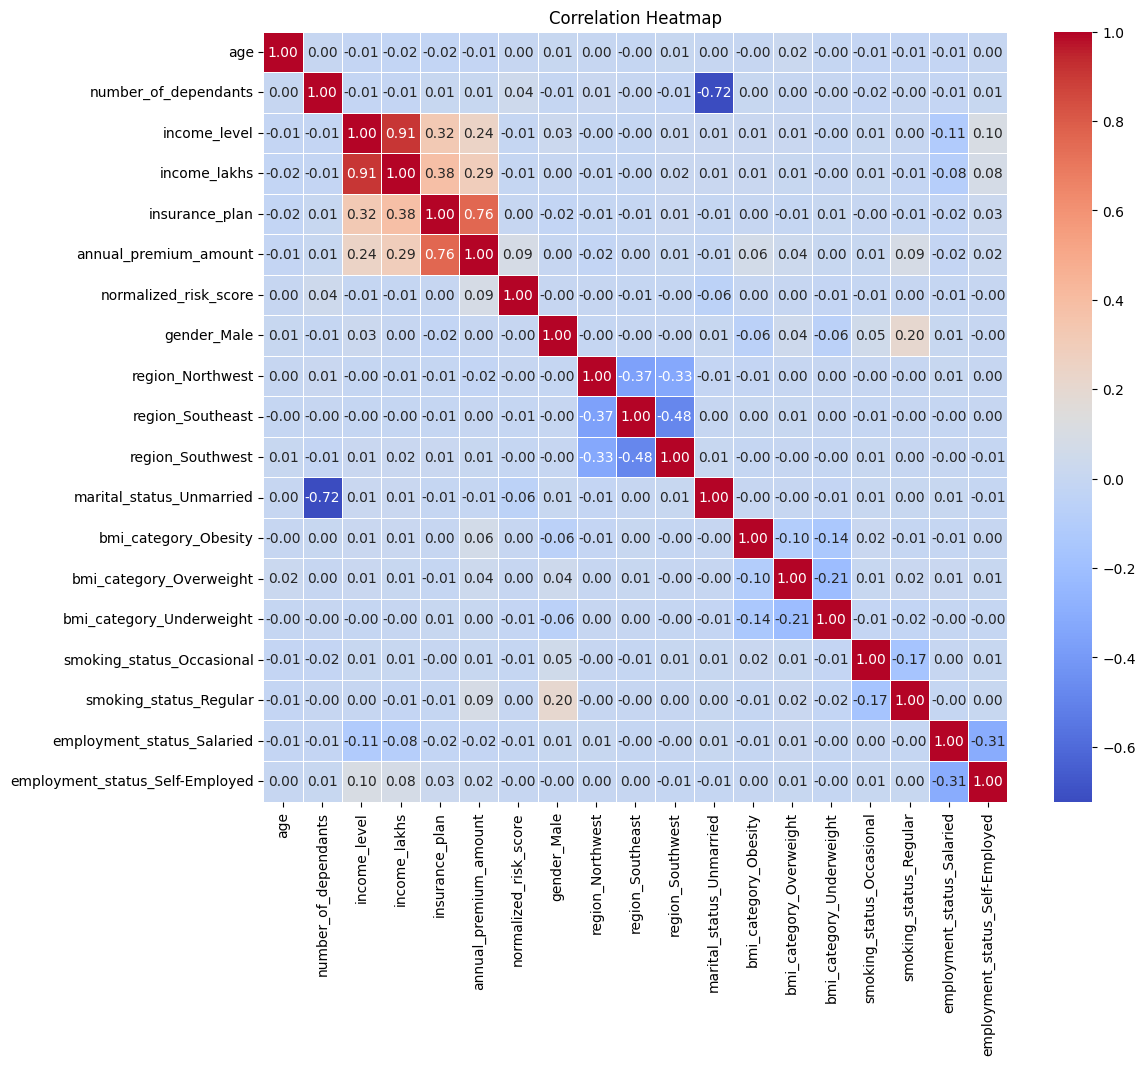

In [50]:
cm = df4.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [51]:
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [52]:
y = df4['annual_premium_amount']
X = df4.drop(columns=['annual_premium_amount'], axis='columns')

from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])
X.head()



,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [53]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.357994,0.216064,0.179578,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.347481,0.219516,0.300051,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
from  statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Column'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

In [55]:
calculate_vif(X)

,Column,VIF
0,age,3.142881
1,number_of_dependants,1.860761
2,income_level,11.928707
3,income_lakhs,11.874242
4,insurance_plan,1.592892
5,normalized_risk_score,1.154223
6,gender_Male,2.310023
7,region_Northwest,2.147701
8,region_Southeast,2.970188
9,region_Southwest,2.730503


In [56]:
calculate_vif(X.drop(columns=['income_level'], axis='columns'))

,Column,VIF
0,age,3.141534
1,number_of_dependants,1.858110
2,income_lakhs,2.291873
3,insurance_plan,1.587794
4,normalized_risk_score,1.154174
5,gender_Male,2.299848
6,region_Northwest,2.146767
7,region_Southeast,2.968993
8,region_Southwest,2.729813
9,marital_status_Unmarried,7.299818


In [57]:
X_reduced = X.drop(columns=['income_level'], axis='columns')
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.020202,0.5,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,0.969697,0.5,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.141414,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.131313,0.0,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


### Model training

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)    
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14060, 17)
X_test shape: (6026, 17)
y_train shape: (14060,)
y_test shape: (6026,)


In [59]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("Test model score:", model_lr.score(X_test, y_test))
print("Train model score:", model_lr.score(X_train, y_train))

Mean Squared Error (MSE): 3042911.242917955
Root Mean Squared Error (RMSE): 1744.394233800936
R-squared (R2): 0.6006143379050812
Test model score: 0.6006143379050812
Train model score: 0.6038233962462742


In [60]:
model_lr.coef_

array([ 2.36884148e+01, -2.81603858e+01,  6.06515998e+01,  6.97000722e+03,
        1.14617372e+03,  2.27709031e+00, -8.85129128e+01, -2.63407586e+00,
        4.00535339e-01,  3.11161583e+00,  8.48014989e+02,  3.85748545e+02,
        1.86980641e+02,  2.89716954e+02,  6.32388157e+02,  7.72265002e+00,
        2.18415123e+01])

In [61]:
feature_importances = model_lr.coef_ 
coef_df = pd.DataFrame(feature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df.sort_values(by='Coefficients',  ascending=True, inplace=True)
print(coef_df)

                                 Coefficients
region_Northwest                   -88.512913
number_of_dependants               -28.160386
region_Southeast                    -2.634076
region_Southwest                     0.400535
gender_Male                          2.277090
marital_status_Unmarried             3.111616
employment_status_Salaried           7.722650
employment_status_Self-Employed     21.841512
age                                 23.688415
income_lakhs                        60.651600
bmi_category_Underweight           186.980641
smoking_status_Occasional          289.716954
bmi_category_Overweight            385.748545
smoking_status_Regular             632.388157
bmi_category_Obesity               848.014989
normalized_risk_score             1146.173723
insurance_plan                    6970.007217


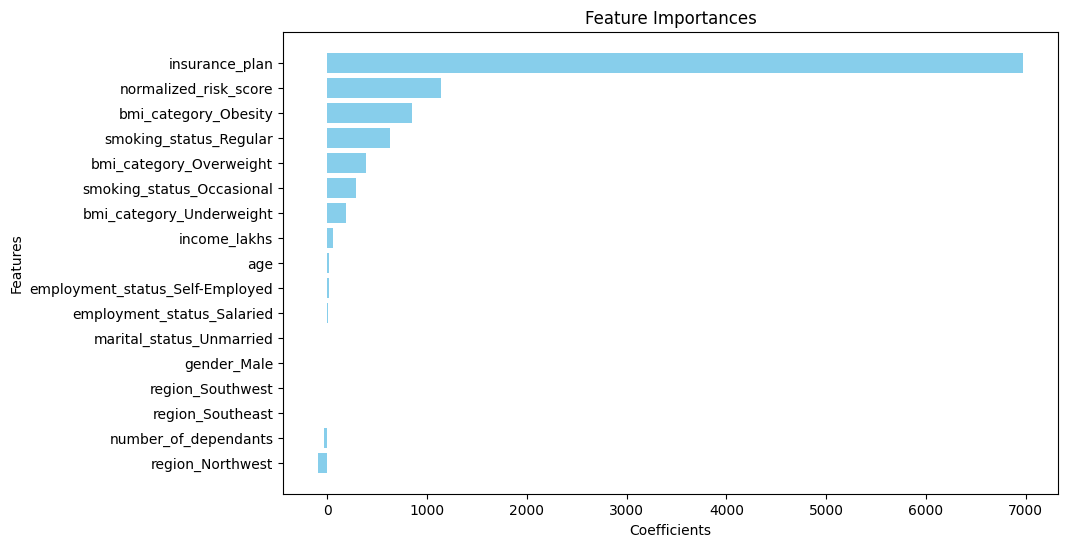

In [62]:

plt.figure(figsize=(10, 6))
plt.barh(coef_df.index, coef_df['Coefficients'], color='skyblue')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.show()

In [63]:
model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train, y_train)

y_pred_rg = model_rg.predict(X_test)
mse_rg = mean_squared_error(y_test, y_pred_rg)
rmse_rg = np.sqrt(mse_rg)
r2_rg = r2_score(y_test, y_pred_rg)

print("Ridge Regression Mean Squared Error (MSE):", mse_rg)
print("Ridge Regression Root Mean Squared Error (RMSE):", rmse_rg)
print("Ridge Regression R-squared (R2):", r2_rg)
print("Ridge Regression Test model score:", model_rg.score(X_test, y_test))
print("Ridge Regression Train model score:", model_rg.score(X_train, y_train))

Ridge Regression Mean Squared Error (MSE): 3042885.6684529963
Ridge Regression Root Mean Squared Error (RMSE): 1744.3869033138824
Ridge Regression R-squared (R2): 0.6006176945835398
Ridge Regression Test model score: 0.6006176945835398
Ridge Regression Train model score: 0.6038229410962823


In [64]:
from xgboost import XGBRegressor
model_xg = XGBRegressor(random_state=42)
model_xg.fit(X_train, y_train)

y_pred_xg = model_xg.predict(X_test)
mse_xg = mean_squared_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mse_xg)
r2_xg = r2_score(y_test, y_pred_xg)

print("XGBoost Regression Mean Squared Error (MSE):", mse_xg)
print("XGBoost Regression Root Mean Squared Error (RMSE):", rmse_xg)
print("XGBoost Regression R-squared (R2):", r2_xg)
print("XGBoost Regression Test model score:", model_xg.score(X_test, y_test))
print("XGBoost Regression Train model score:", model_xg.score(X_train, y_train))

XGBoost Regression Mean Squared Error (MSE): 3371281.25
XGBoost Regression Root Mean Squared Error (RMSE): 1836.1049125798886
XGBoost Regression R-squared (R2): 0.5575153827667236
XGBoost Regression Test model score: 0.5575153827667236
XGBoost Regression Train model score: 0.7264308333396912


In [65]:
# Compatibility patch for sklearn 1.6 + older xgboost wrappers
from sklearn.base import RegressorMixin
from sklearn.utils._tags import Tags, TargetTags, RegressorTags

def _patched_sklearn_tags(self):
    return Tags(
        estimator_type='regressor',
        target_tags=TargetTags(required=True),
        regressor_tags=RegressorTags(),
    )

RegressorMixin.__sklearn_tags__ = _patched_sklearn_tags

model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
random_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}
0.6013959646224976


In [66]:
best_model = random_search.best_estimator_

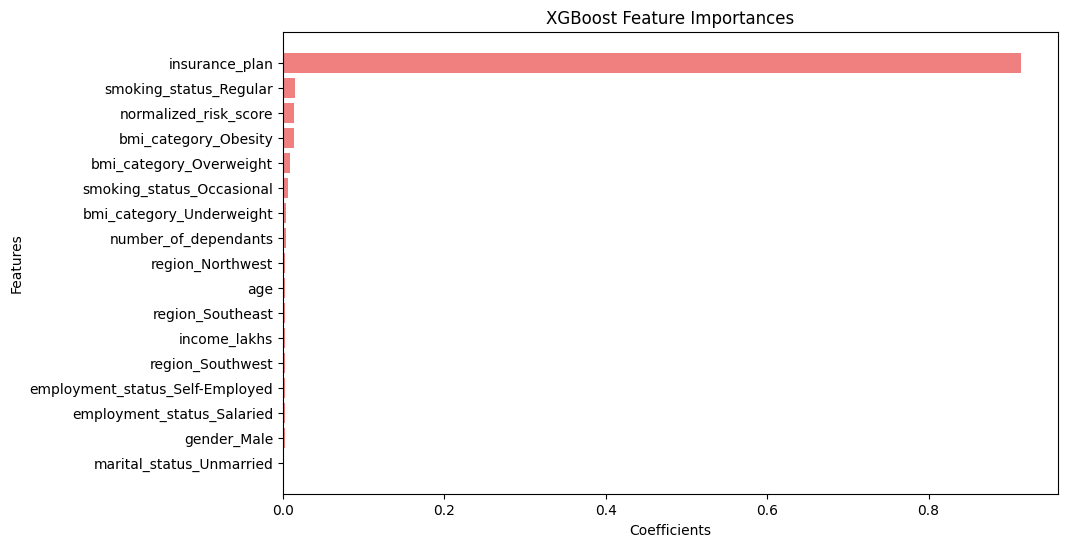

In [67]:
frature_importances = best_model.feature_importances_
coef_df_xgb = pd.DataFrame(frature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df_xgb.sort_values(by='Coefficients', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_df_xgb.index, coef_df_xgb['Coefficients'], color='lightcoral')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("XGBoost Feature Importances")
plt.show()

### Error Analysis

In [68]:
y_pred_xgb = best_model.predict(X_test)

residuals = y_test - y_pred_xgb
residuals_pct = residuals*100 / y_test

residuals_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_xgb,
    'Residuals': residuals,
    'Residuals (%)': residuals_pct
})
residuals_df.head(10)

,Actual,Predicted,Residuals,Residuals (%)
10489,5452,6904.088379,-1452.088379,-26.634050
7989,9658,7496.944336,2161.055664,22.375809
3113,6031,8417.112305,-2386.112305,-39.564124
10605,12386,10394.381836,1991.618164,16.079591
4204,4245,7108.754395,-2863.754395,-67.461823
16419,15874,13430.024414,2443.975586,15.396092
6534,12921,10008.745117,2912.254883,22.538928
1712,5184,6984.361328,-1800.361328,-34.729192
15712,7955,7328.594238,626.405762,7.874365
10360,9282,7572.237305,1709.762695,18.420197


<Axes: xlabel='Residuals (%)', ylabel='Count'>

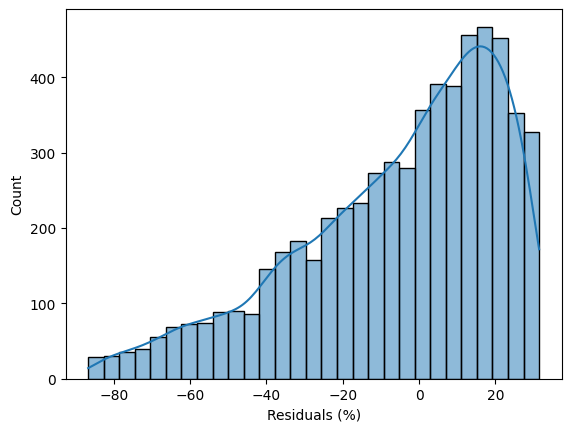

In [69]:
sns.histplot(residuals_df['Residuals (%)'], kde=True)

In [70]:
extreme_error_threshold = 10
extreme_results_df = residuals_df[np.abs(residuals_df['Residuals (%)']) > extreme_error_threshold]
extreme_results_df.shape

(4392, 4)

In [71]:
extreme_error_percentage = extreme_results_df.shape[0]*100 / residuals_df.shape[0]
extreme_error_percentage

72.88416860272154

In [72]:
residuals_df[np.abs(residuals_df['Residuals (%)']) > 50].sort_values(by='Residuals (%)', ascending=False).head(10)

,Actual,Predicted,Residuals,Residuals (%)
11907,4504,6756.419434,-2252.419434,-50.009312
4086,4592,6888.580566,-2296.580566,-50.012643
6072,4419,6629.513672,-2210.513672,-50.022939
17680,4655,6984.361328,-2329.361328,-50.039986
14024,4415,6629.513672,-2214.513672,-50.158860
4641,4495,6756.419434,-2261.419434,-50.309665
577,4348,6536.259766,-2188.259766,-50.327961
6497,4728,7108.754395,-2380.754395,-50.354365
4671,4493,6756.419434,-2263.419434,-50.376573
15966,4709,7082.545410,-2373.545410,-50.404447


In [73]:
X_test.index

Index([10489,  7989,  3113, 10605,  4204, 16419,  6534,  1712, 15712, 10360,
       ...
       12378,  2039,  1023,  8235, 18542, 18960,   266, 10036, 15506, 10890],
      dtype='int64', length=6026)

In [74]:
extreme_results_df.index

Index([10489,  7989,  3113, 10605,  4204, 16419,  6534,  1712, 10360, 18164,
       ...
        6215, 17331, 12378,  1023,  8235, 18542, 18960,   266, 10036, 10890],
      dtype='int64', length=4392)

In [75]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
10489,0.428571,1.0,0.080808,0.0,0.428571,1,0,0,0,0,0,0,0,0,0,0,0
7989,0.714286,0.0,0.030303,0.0,1.000000,1,0,0,1,1,0,0,0,0,0,0,0
3113,0.142857,0.0,0.363636,0.0,1.000000,1,0,0,1,1,0,0,0,0,1,1,0
10605,0.428571,0.0,0.515152,0.5,0.428571,1,0,1,0,1,0,1,0,0,0,0,0
4204,0.000000,0.0,0.222222,0.0,0.000000,0,0,1,0,1,0,0,1,0,1,0,0


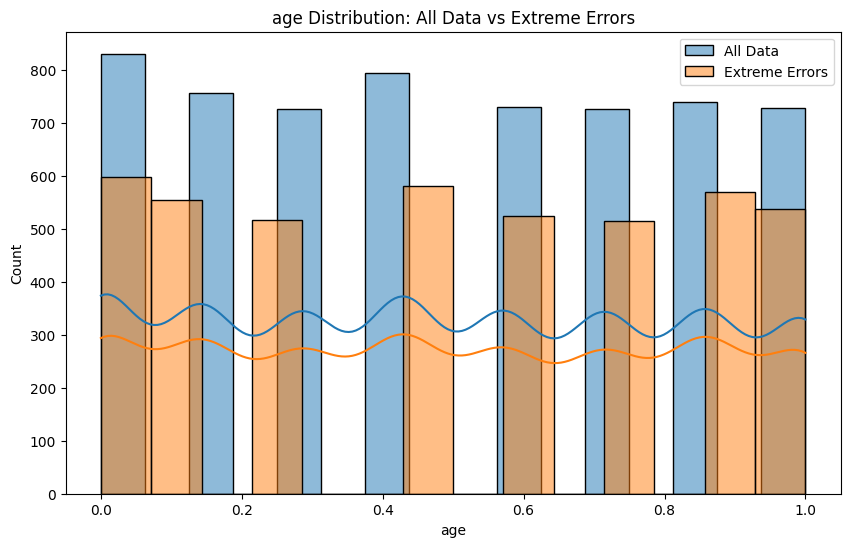

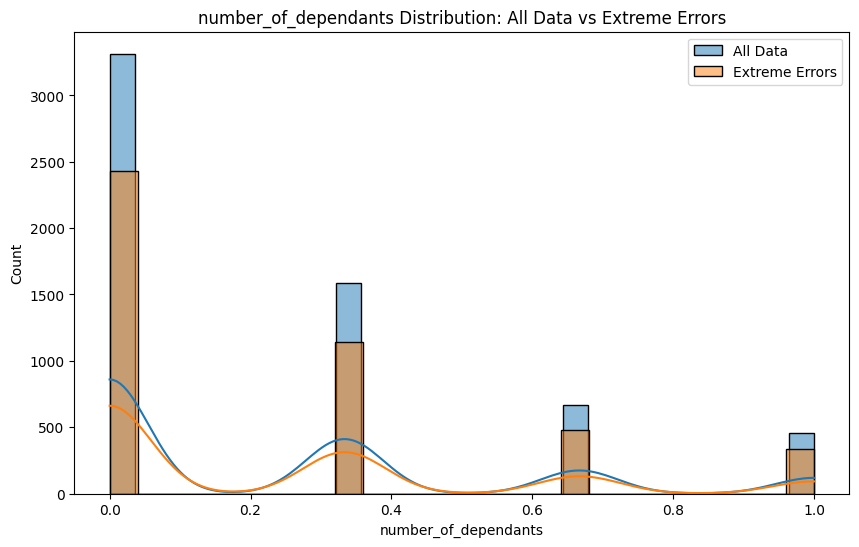

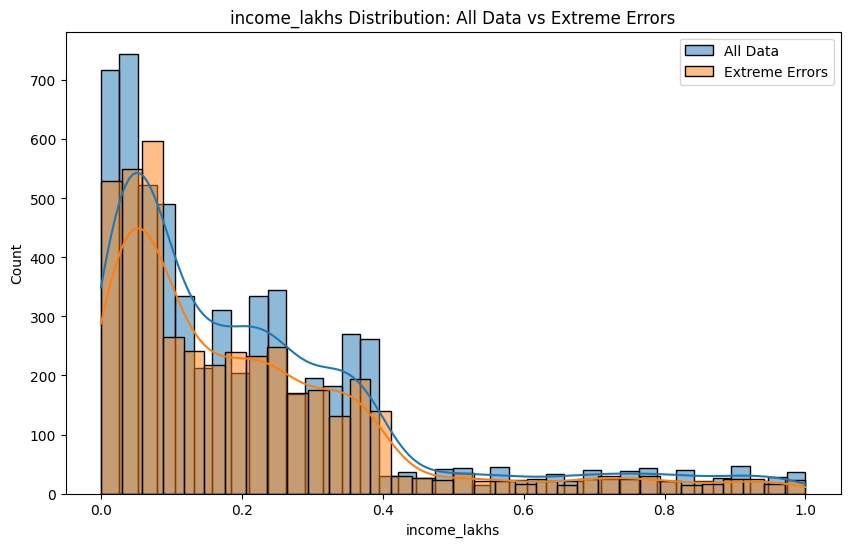

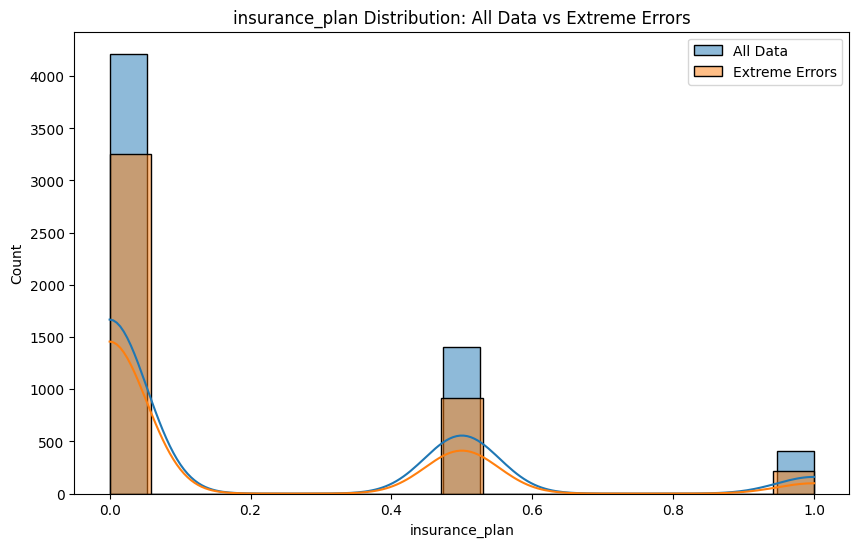

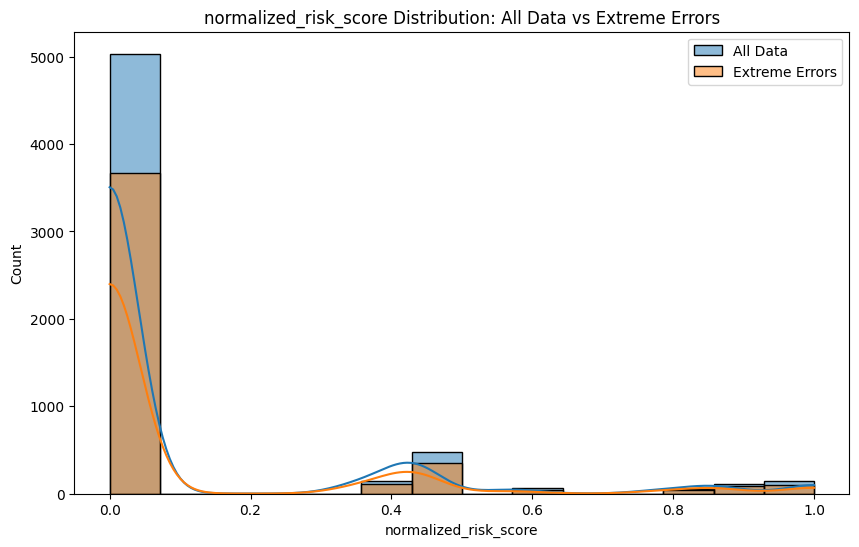

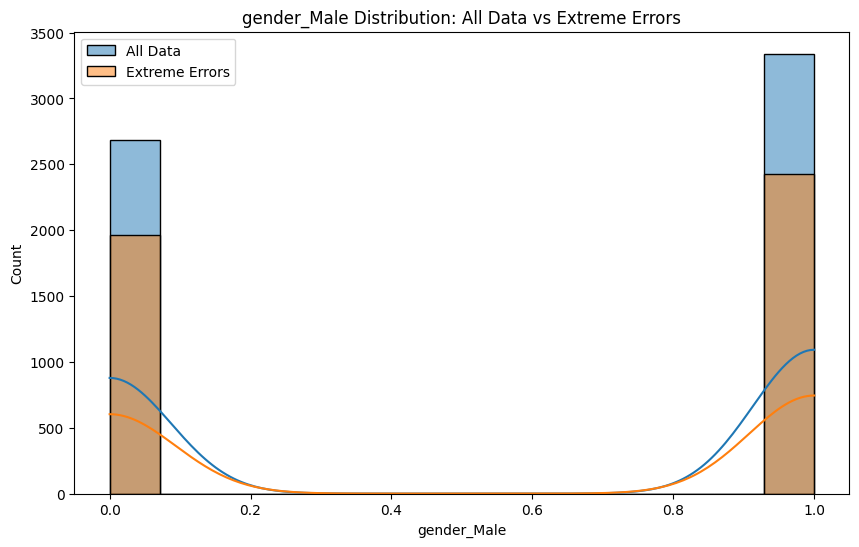

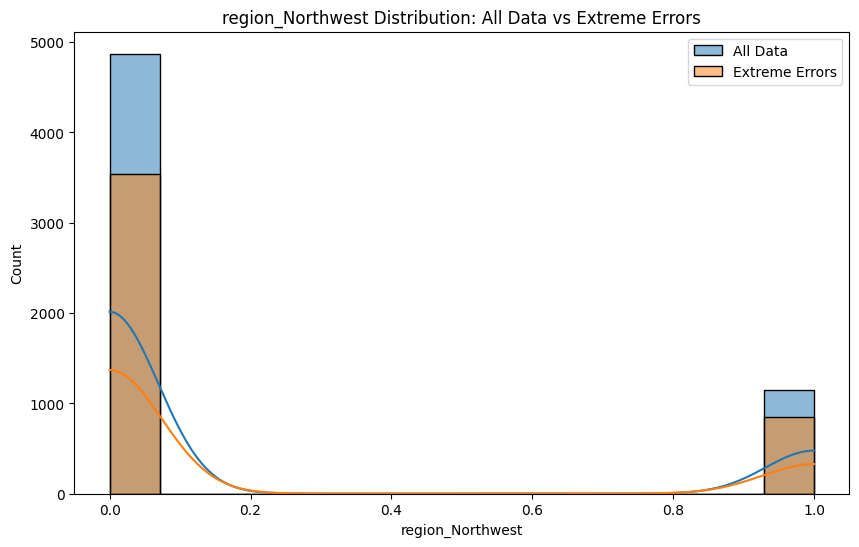

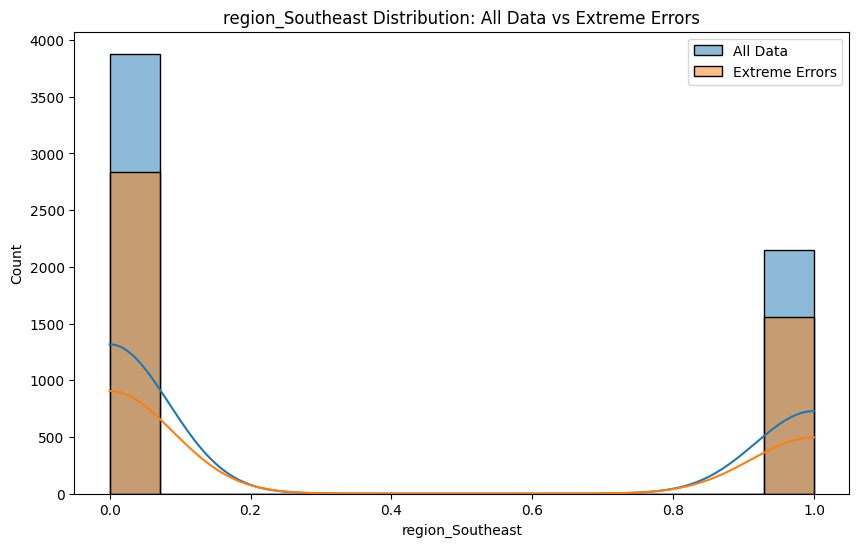

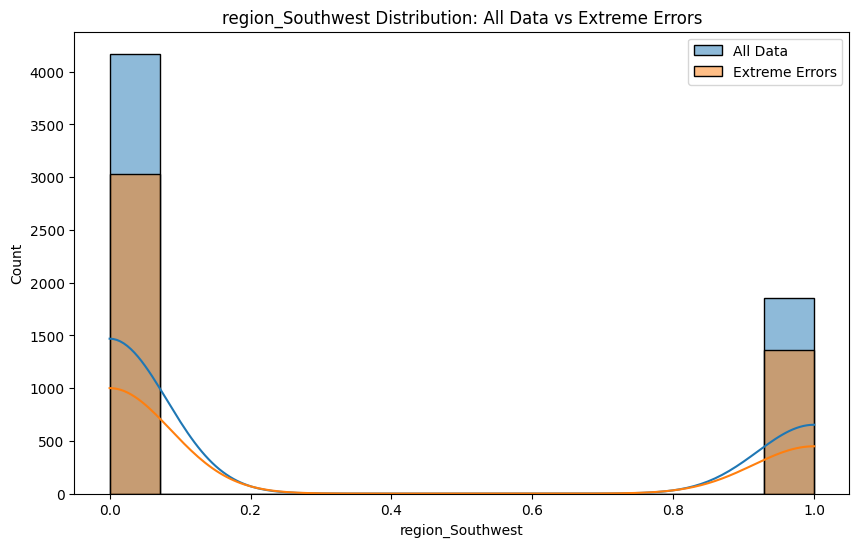

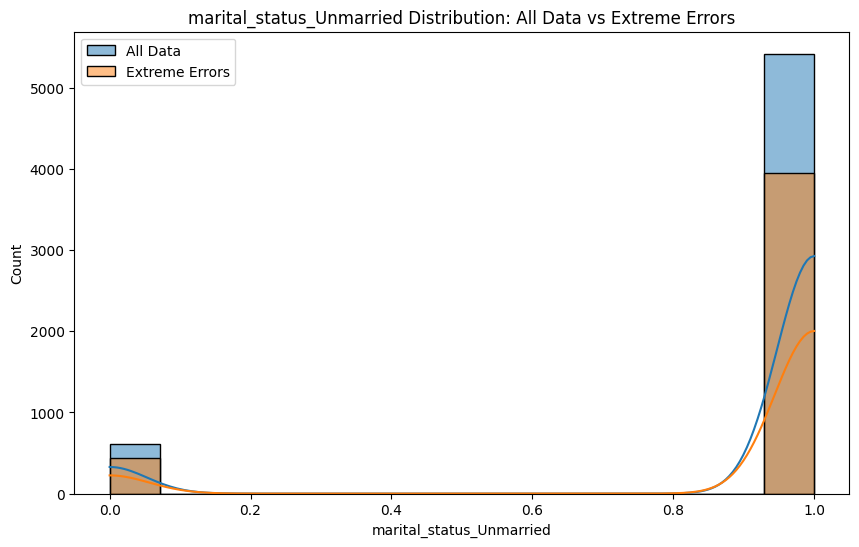

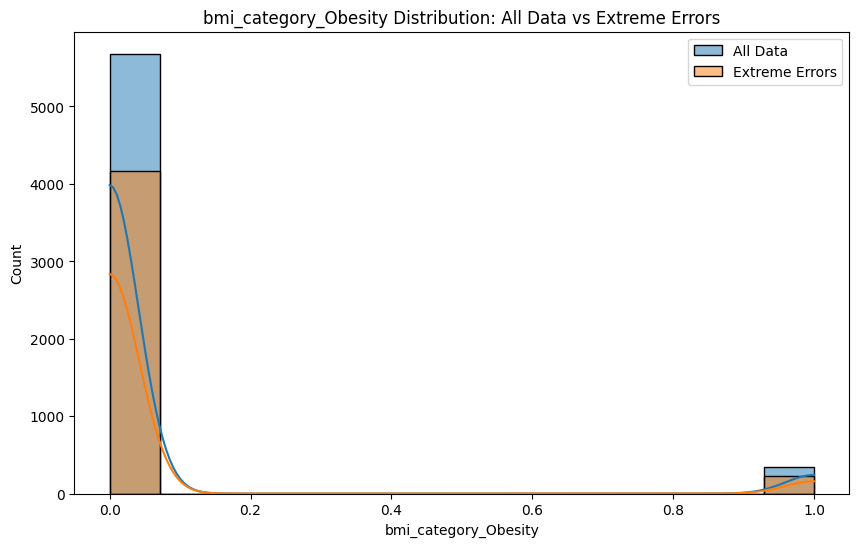

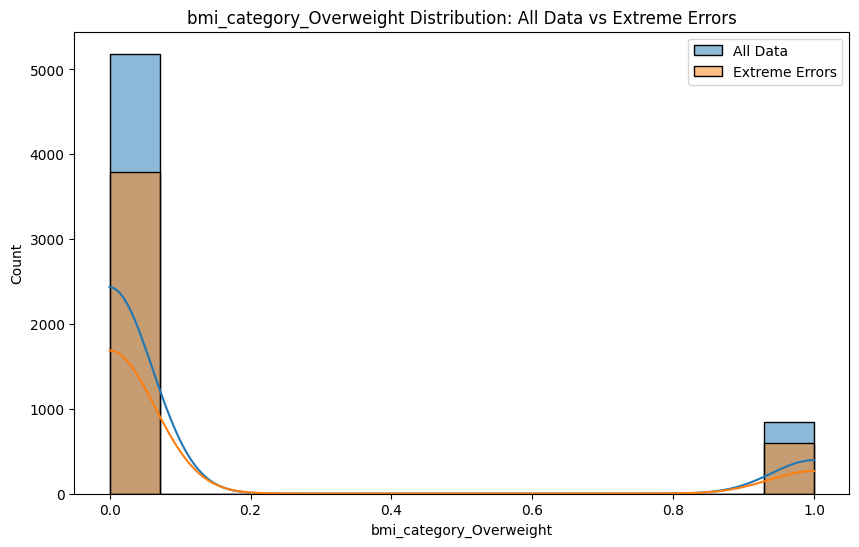

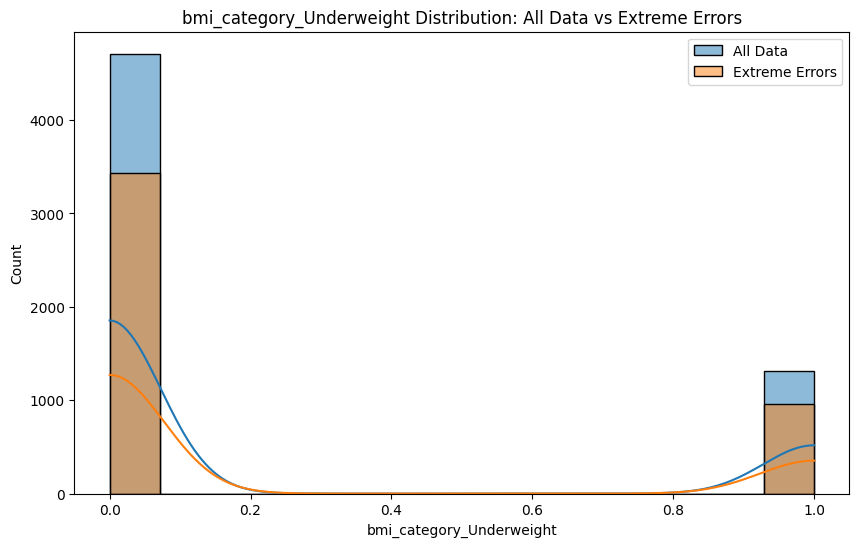

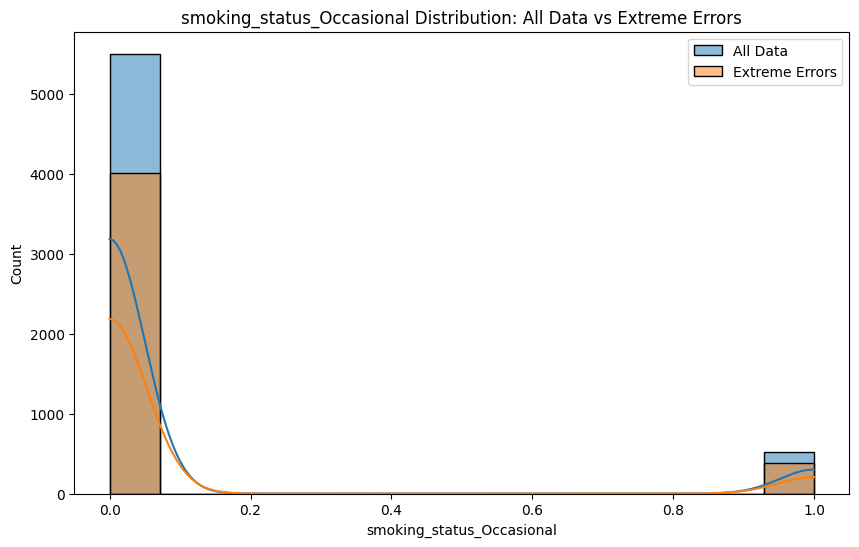

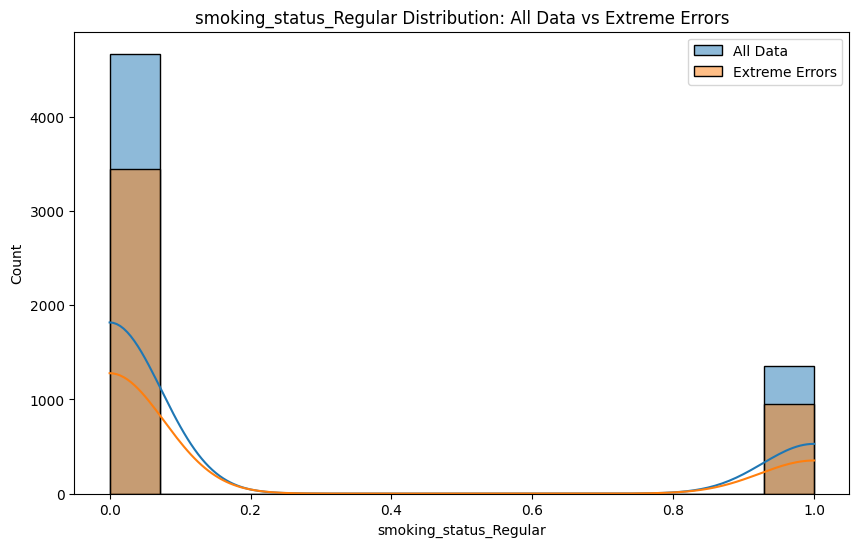

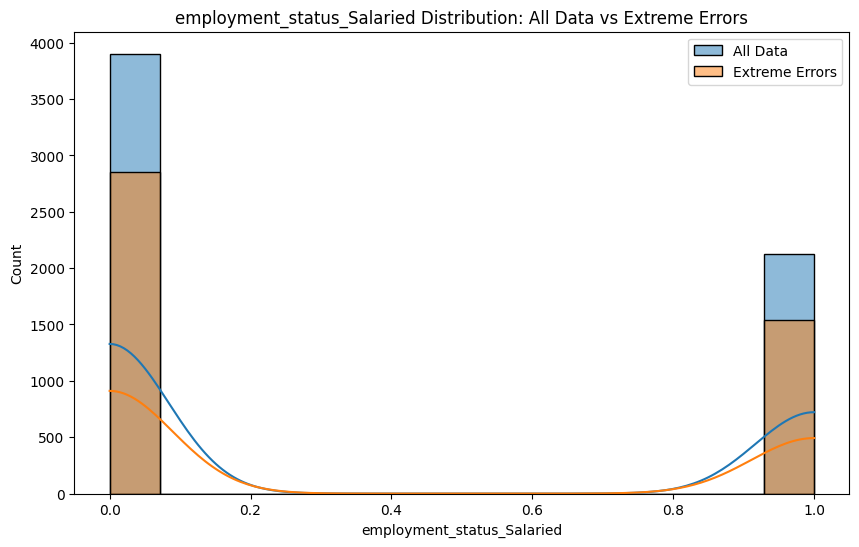

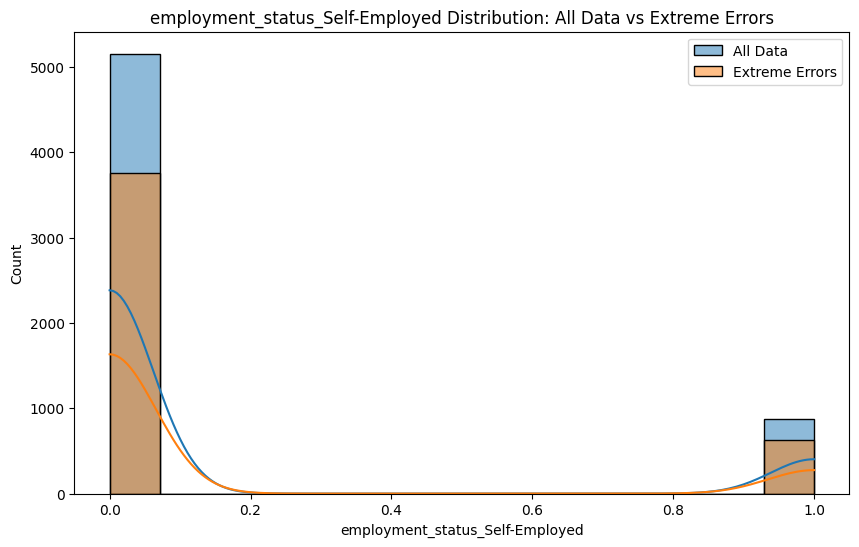

In [76]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_test[feature], label='All Data', kde=True)
    sns.histplot(extreme_errors_df[feature], label='Extreme Errors', kde=True)
    plt.legend()
    plt.title(f'{feature} Distribution: All Data vs Extreme Errors')
    plt.show()

In [77]:
cols_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan']

In [78]:
extreme_errors_df['income_level'] = -1

<Axes: xlabel='age', ylabel='Count'>

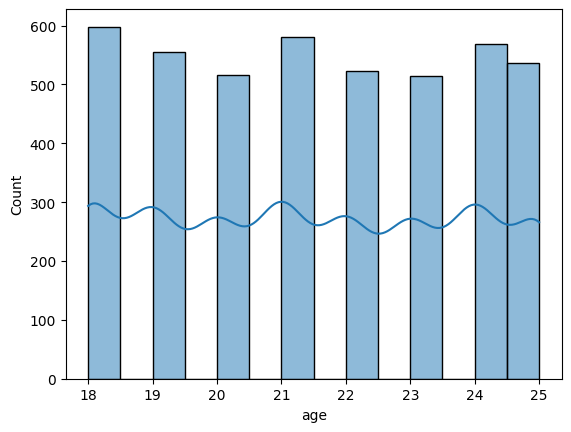

In [79]:
df_reversed = pd.DataFrame() 
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])

df_reversed

sns.histplot(df_reversed['age'], kde=True)

In [ ]:
df_reversed['age'].quantile(0.97)

np.float64(25.0)

: 